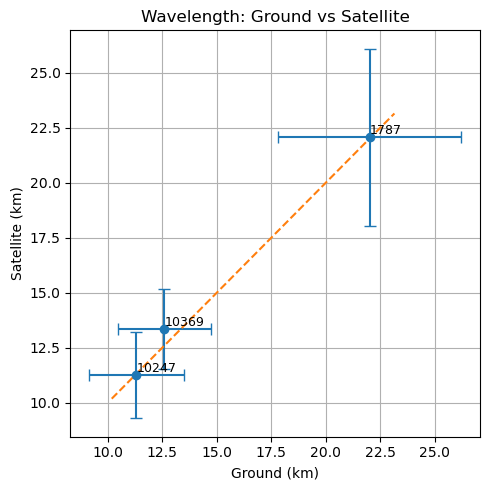

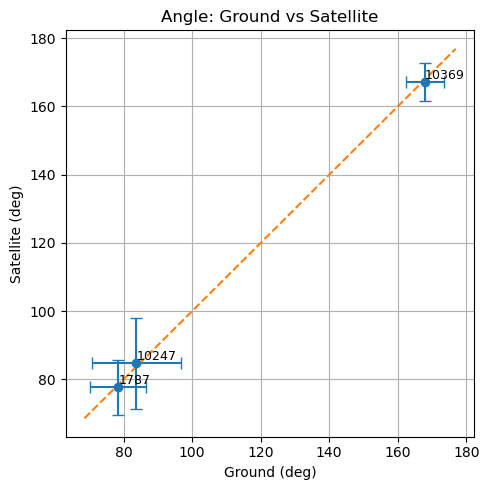

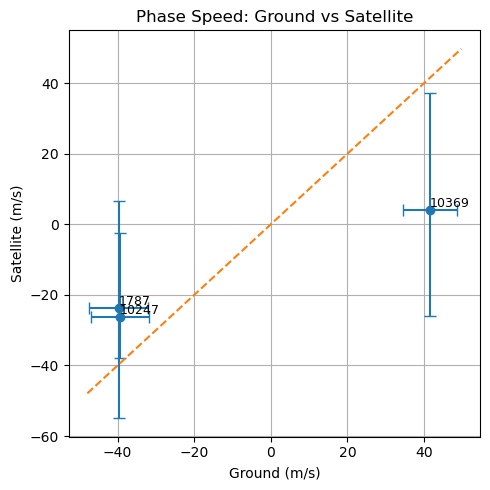

In [2]:
# %%
import numpy as np
import matplotlib.pyplot as plt

# -------------------------
# Data
# -------------------------
orbits = np.array([10369, 10247, 1787])

# Satellite
sat_wavelength = np.array([13.34860401, 11.25992588, 22.07457137])
sat_wavelength_err = np.array([1.83254737, 1.971435822, 4.024633342])

sat_angle = np.array([167.1261217, 84.70450607, 77.62716528])
sat_angle_err = np.array([5.576604682, 13.36889586, 8.096342713])

sat_phase = np.array([4.073122014, -26.18311889, -23.80727657])

# remap bounds → asymmetric error
sat_phase_low = np.array([-25.93959503, -38.02595979, -54.96363946])
sat_phase_high = np.array([37.19473875, -2.533266119, 6.716997702])

sat_phase_err_lower = sat_phase - sat_phase_low
sat_phase_err_upper = sat_phase_high - sat_phase

# Ground
grd_wavelength = np.array([12.6, 11.31, 22.02])
grd_wavelength_err = np.array([2.14, 2.18, 4.21])

grd_angle = np.array([167.88, 83.77, 78.44])
grd_angle_err = np.array([5.52, 12.93, 8.13])

grd_phase = np.array([41.58, -39.38, -39.77])
grd_phase_err = np.array([7.05, 7.59, 7.61])

# -------------------------
# Helper: 1:1 plot + labels
# -------------------------
def plot_comparison(x, y, xerr, yerr, title, xlabel, ylabel):
    plt.figure(figsize=(5,5))

    plt.errorbar(
        x, y,
        xerr=xerr,
        yerr=yerr,
        fmt='o',
        capsize=4
    )

    # label each orbit
    for i, orbit in enumerate(orbits):
        plt.text(
            x[i], y[i],
            f"{orbit}",
            fontsize=9,
            ha='left',
            va='bottom'
        )

    # 1:1 line
    all_vals = np.concatenate([x, y])
    vmin, vmax = np.min(all_vals), np.max(all_vals)
    pad = 0.1 * (vmax - vmin)

    plt.plot([vmin-pad, vmax+pad], [vmin-pad, vmax+pad], linestyle='--')

    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True)

    plt.tight_layout()
    plt.show()

# -------------------------
# 1. Wavelength
# -------------------------
plot_comparison(
    grd_wavelength,
    sat_wavelength,
    grd_wavelength_err,
    sat_wavelength_err,
    "Wavelength: Ground vs Satellite",
    "Ground (km)",
    "Satellite (km)"
)

# -------------------------
# 2. Angle
# -------------------------
plot_comparison(
    grd_angle,
    sat_angle,
    grd_angle_err,
    sat_angle_err,
    "Angle: Ground vs Satellite",
    "Ground (deg)",
    "Satellite (deg)"
)

# -------------------------
# 3. Phase Speed
# -------------------------
plt.figure(figsize=(5,5))

plt.errorbar(
    grd_phase,
    sat_phase,
    xerr=grd_phase_err,
    yerr=[sat_phase_err_lower, sat_phase_err_upper],
    fmt='o',
    capsize=4
)

# label each orbit
for i, orbit in enumerate(orbits):
    plt.text(
        grd_phase[i], sat_phase[i],
        f"{orbit}",
        fontsize=9,
        ha='left',
        va='bottom'
    )

# 1:1 line
all_vals = np.concatenate([grd_phase, sat_phase])
vmin, vmax = np.min(all_vals), np.max(all_vals)
pad = 0.1 * (vmax - vmin)

plt.plot([vmin-pad, vmax+pad], [vmin-pad, vmax+pad], linestyle='--')

plt.xlabel("Ground (m/s)")
plt.ylabel("Satellite (m/s)")
plt.title("Phase Speed: Ground vs Satellite")
plt.grid(True)

plt.tight_layout()
plt.show()

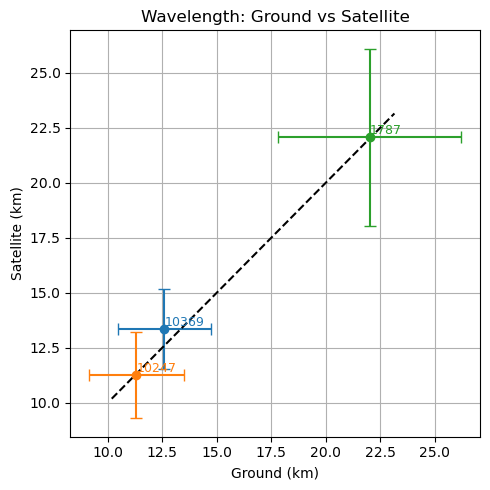

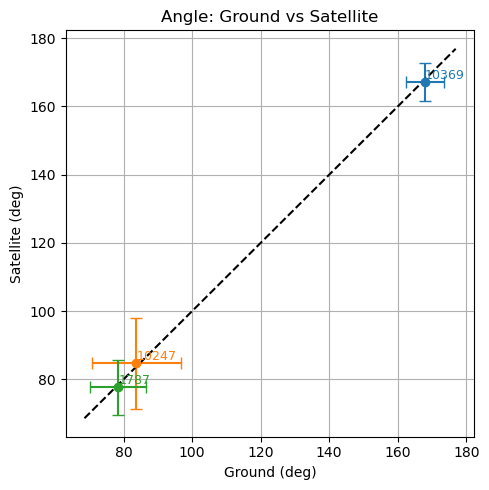

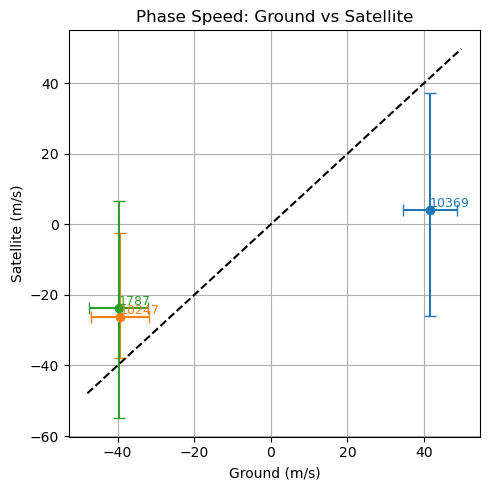

In [5]:
# %%
import numpy as np
import matplotlib.pyplot as plt

# -------------------------
# Colors per orbit
# -------------------------
colors = plt.cm.tab10(np.arange(len(orbits)))

# -------------------------
# Helper: 1:1 plot + colors
# -------------------------
def plot_comparison(x, y, xerr, yerr, title, xlabel, ylabel):
    plt.figure(figsize=(5,5))

    for i in range(len(orbits)):
        plt.errorbar(
            x[i], y[i],
            xerr=xerr[i],
            yerr=yerr[i],
            fmt='o',
            capsize=4,
            color=colors[i],
            label=f"Orbit {orbits[i]}"
        )

        plt.text(
            x[i], y[i],
            f"{orbits[i]}",
            fontsize=9,
            ha='left',
            va='bottom',
            color=colors[i]
        )

    # 1:1 line
    all_vals = np.concatenate([x, y])
    vmin, vmax = np.min(all_vals), np.max(all_vals)
    pad = 0.1 * (vmax - vmin)

    plt.plot([vmin-pad, vmax+pad], [vmin-pad, vmax+pad],
             linestyle='--', color='black')

    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True)
    #plt.legend()

    plt.tight_layout()
    plt.show()

# -------------------------
# 1. Wavelength
# -------------------------
plot_comparison(
    grd_wavelength,
    sat_wavelength,
    grd_wavelength_err,
    sat_wavelength_err,
    "Wavelength: Ground vs Satellite",
    "Ground (km)",
    "Satellite (km)"
)

# -------------------------
# 2. Angle
# -------------------------
plot_comparison(
    grd_angle,
    sat_angle,
    grd_angle_err,
    sat_angle_err,
    "Angle: Ground vs Satellite",
    "Ground (deg)",
    "Satellite (deg)"
)

# -------------------------
# 3. Phase Speed (custom y error)
# -------------------------
plt.figure(figsize=(5,5))

for i in range(len(orbits)):
    plt.errorbar(
        grd_phase[i], sat_phase[i],
        xerr=grd_phase_err[i],
        yerr=[[sat_phase_err_lower[i]], [sat_phase_err_upper[i]]],
        fmt='o',
        capsize=4,
        color=colors[i],
        label=f"Orbit {orbits[i]}"
    )

    plt.text(
        grd_phase[i], sat_phase[i],
        f"{orbits[i]}",
        fontsize=9,
        ha='left',
        va='bottom',
        color=colors[i]
    )

# 1:1 line
all_vals = np.concatenate([grd_phase, sat_phase])
vmin, vmax = np.min(all_vals), np.max(all_vals)
pad = 0.1 * (vmax - vmin)

plt.plot([vmin-pad, vmax+pad], [vmin-pad, vmax+pad],
         linestyle='--', color='black')

plt.xlabel("Ground (m/s)")
plt.ylabel("Satellite (m/s)")
plt.title("Phase Speed: Ground vs Satellite")
plt.grid(True)
#plt.legend()

plt.tight_layout()
plt.show()

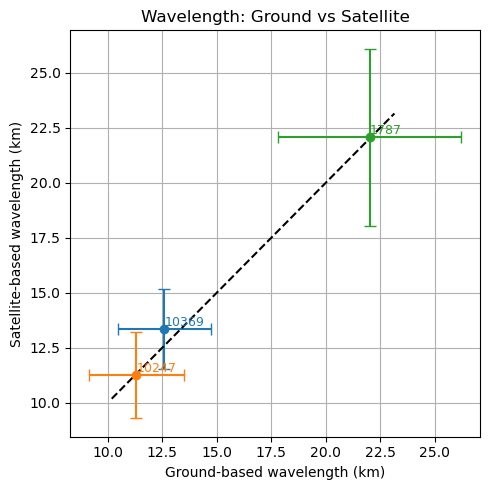

Saved: comparison_plots_remap85\wavelength_ground_vs_satellite.png
Saved: comparison_plots_remap85\wavelength_ground_vs_satellite.pdf


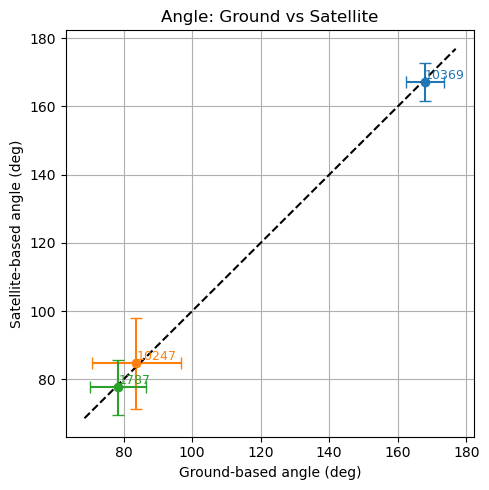

Saved: comparison_plots_remap85\angle_ground_vs_satellite.png
Saved: comparison_plots_remap85\angle_ground_vs_satellite.pdf


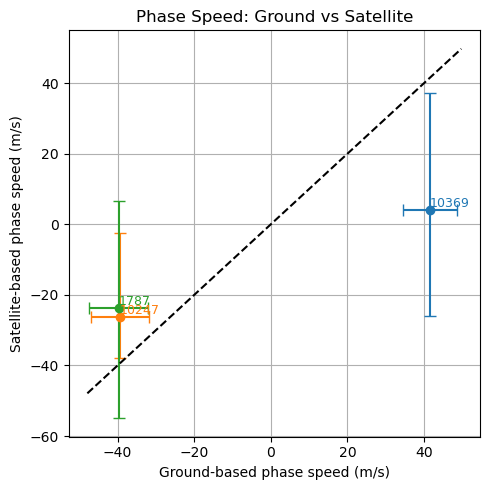

Saved: comparison_plots_remap85\phase_speed_ground_vs_satellite.png
Saved: comparison_plots_remap85\phase_speed_ground_vs_satellite.pdf


In [6]:
# %%
import os
import numpy as np
import matplotlib.pyplot as plt

# -------------------------
# Output folder
# -------------------------
output_dir = "comparison_plots_remap85"
os.makedirs(output_dir, exist_ok=True)

# -------------------------
# Data
# -------------------------
orbits = np.array([10369, 10247, 1787])

# Satellite
sat_wavelength = np.array([13.34860401, 11.25992588, 22.07457137])
sat_wavelength_err = np.array([1.83254737, 1.971435822, 4.024633342])

sat_angle = np.array([167.1261217, 84.70450607, 77.62716528])
sat_angle_err = np.array([5.576604682, 13.36889586, 8.096342713])

sat_phase = np.array([4.073122014, -26.18311889, -23.80727657])

# remap bounds → asymmetric satellite phase-speed error
sat_phase_low = np.array([-25.93959503, -38.02595979, -54.96363946])
sat_phase_high = np.array([37.19473875, -2.533266119, 6.716997702])

sat_phase_err_lower = sat_phase - sat_phase_low
sat_phase_err_upper = sat_phase_high - sat_phase

# Ground
grd_wavelength = np.array([12.6, 11.31, 22.02])
grd_wavelength_err = np.array([2.14, 2.18, 4.21])

grd_angle = np.array([167.88, 83.77, 78.44])
grd_angle_err = np.array([5.52, 12.93, 8.13])

grd_phase = np.array([41.58, -39.38, -39.77])
grd_phase_err = np.array([7.05, 7.59, 7.61])

# -------------------------
# Colors per orbit
# -------------------------
colors = plt.cm.tab10(np.arange(len(orbits)))

# -------------------------
# Helper function
# -------------------------
def plot_comparison(x, y, xerr, yerr, title, xlabel, ylabel, filename):
    plt.figure(figsize=(5, 5))

    for i in range(len(orbits)):
        plt.errorbar(
            x[i],
            y[i],
            xerr=xerr[i],
            yerr=yerr[i],
            fmt="o",
            capsize=4,
            color=colors[i],
            label=f"Orbit {orbits[i]}"
        )

        plt.text(
            x[i],
            y[i],
            f"{orbits[i]}",
            fontsize=9,
            ha="left",
            va="bottom",
            color=colors[i]
        )

    # 1:1 line
    all_vals = np.concatenate([x, y])
    vmin, vmax = np.nanmin(all_vals), np.nanmax(all_vals)
    pad = 0.1 * (vmax - vmin)

    plt.plot(
        [vmin - pad, vmax + pad],
        [vmin - pad, vmax + pad],
        linestyle="--",
        color="black",
        label="1:1"
    )

    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True)

    plt.tight_layout()

    png_path = os.path.join(output_dir, f"{filename}.png")
    pdf_path = os.path.join(output_dir, f"{filename}.pdf")

    plt.savefig(png_path, dpi=300, bbox_inches="tight")
    plt.savefig(pdf_path, bbox_inches="tight")

    plt.show()

    print(f"Saved: {png_path}")
    print(f"Saved: {pdf_path}")

# -------------------------
# 1. Wavelength
# -------------------------
plot_comparison(
    grd_wavelength,
    sat_wavelength,
    grd_wavelength_err,
    sat_wavelength_err,
    "Wavelength: Ground vs Satellite",
    "Ground-based wavelength (km)",
    "Satellite-based wavelength (km)",
    "wavelength_ground_vs_satellite"
)

# -------------------------
# 2. Angle
# -------------------------
plot_comparison(
    grd_angle,
    sat_angle,
    grd_angle_err,
    sat_angle_err,
    "Angle: Ground vs Satellite",
    "Ground-based angle (deg)",
    "Satellite-based angle (deg)",
    "angle_ground_vs_satellite"
)

# -------------------------
# 3. Phase speed
# -------------------------
plt.figure(figsize=(5, 5))

for i in range(len(orbits)):
    plt.errorbar(
        grd_phase[i],
        sat_phase[i],
        xerr=grd_phase_err[i],
        yerr=[[sat_phase_err_lower[i]], [sat_phase_err_upper[i]]],
        fmt="o",
        capsize=4,
        color=colors[i],
        label=f"Orbit {orbits[i]}"
    )

    plt.text(
        grd_phase[i],
        sat_phase[i],
        f"{orbits[i]}",
        fontsize=9,
        ha="left",
        va="bottom",
        color=colors[i]
    )

# 1:1 line
all_vals = np.concatenate([grd_phase, sat_phase])
vmin, vmax = np.nanmin(all_vals), np.nanmax(all_vals)
pad = 0.1 * (vmax - vmin)

plt.plot(
    [vmin - pad, vmax + pad],
    [vmin - pad, vmax + pad],
    linestyle="--",
    color="black",
    label="1:1"
)

plt.xlabel("Ground-based phase speed (m/s)")
plt.ylabel("Satellite-based phase speed (m/s)")
plt.title("Phase Speed: Ground vs Satellite")
plt.grid(True)

plt.tight_layout()

png_path = os.path.join(output_dir, "phase_speed_ground_vs_satellite.png")
pdf_path = os.path.join(output_dir, "phase_speed_ground_vs_satellite.pdf")

plt.savefig(png_path, dpi=300, bbox_inches="tight")
plt.savefig(pdf_path, bbox_inches="tight")

plt.show()

print(f"Saved: {png_path}")
print(f"Saved: {pdf_path}")

## 8 orbits

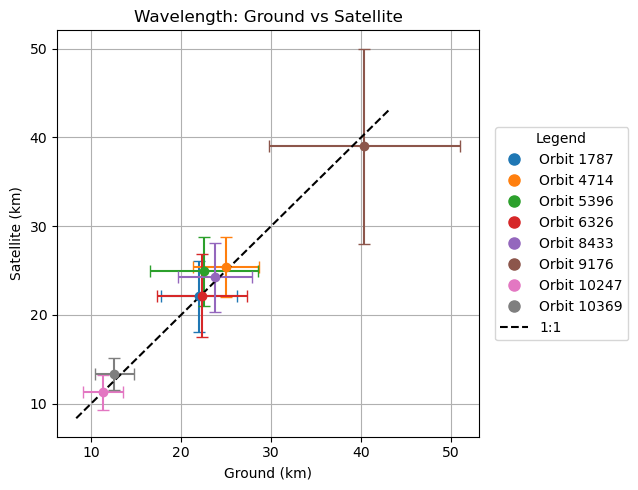

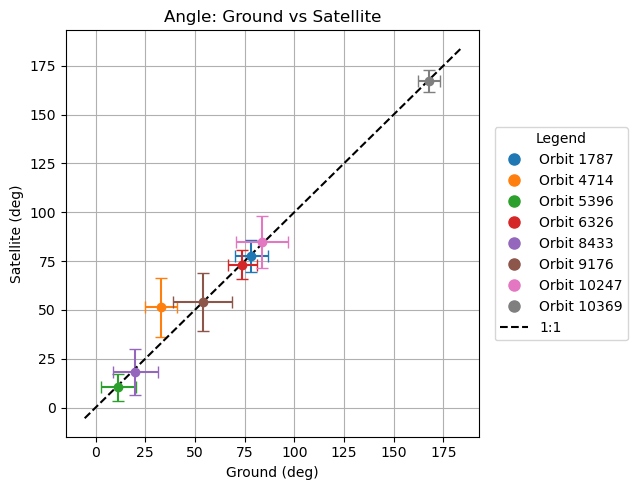

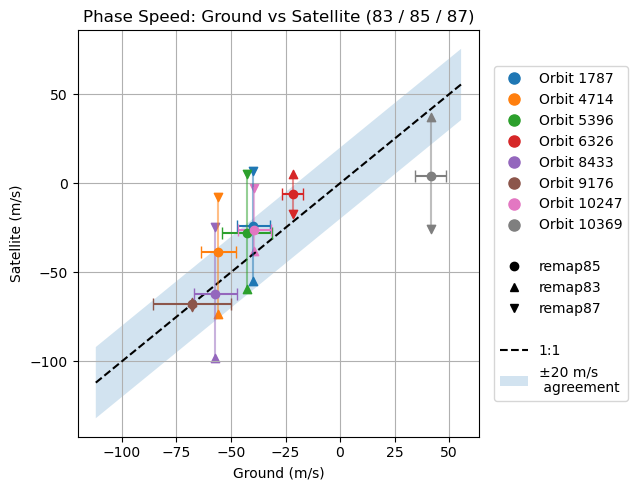

In [4]:
# %%
import os
import numpy as np
import matplotlib.pyplot as plt

# -------------------------
# Output folder
# -------------------------
output_dir = "comparison_plots_remap85"
os.makedirs(output_dir, exist_ok=True)

# -------------------------
# Data
# -------------------------
orbits = np.array([10369, 10247, 1787, 5396, 6326, 4714, 8433, 9176])

sat_wavelength = np.array([13.34860401, 11.25992588, 22.07457137, 24.92825442, 22.18156909, 25.39853246, 24.24548703, 38.98515267])
sat_wavelength_err = np.array([1.83254737, 1.971435822, 4.024633342, 3.88046428, 4.676718402, 3.430036487, 3.903323291, 11.00888072])

sat_angle = np.array([167.1261217, 84.70450607, 77.62716528, 10.30053347, 73.1331518, 51.36259019, 18.09747472, 54.03530959])
sat_angle_err = np.array([5.576604682, 13.36889586, 8.096342713, 6.947045102, 7.347474371, 15.21938847, 11.75563646, 14.69947478])

sat_phase = np.array([4.073122014, -26.18311889, -23.80727657, -27.67183124, -6.068190197, -38.68305528, -62.18263325, -67.68255671])
sat_phase_err = np.array([0.559173756, 4.584252069, 4.340539958, 4.307543998, 1.279405287, 5.22409282, 10.0108907, 19.11264014])

sat_phase_83 = np.array([37.19473875, -38.02595979, -54.96363946, -59.18907437, 5.012266203, -73.46913979, -98.05627547, -66.79302786])
sat_phase_87 = np.array([-25.93959503, -2.533266119, 6.716997702, 5.228221701, -17.29220013, -7.978575738, -24.81531397, -69.47646983])

grd_wavelength = np.array([12.6, 11.31, 22.02, 22.54, 22.31, 25.01, 23.78, 40.38])
grd_wavelength_err = np.array([2.14, 2.18, 4.21, 6.04, 4.96, 3.65, 4.14, 10.63])

grd_angle = np.array([167.88, 83.77, 78.44, 11.53, 73.79, 32.81, 20.01, 53.88])
grd_angle_err = np.array([5.52, 12.93, 8.13, 8.97, 7.32, 7.95, 11.33, 14.69])

grd_phase = np.array([41.58, -39.38, -39.77, -42.55, -21.63, -55.76, -57.24, -68.05])
grd_phase_err = np.array([7.05, 7.59, 7.61, 11.4, 4.81, 8.13, 9.96, 17.92])

# -------------------------
# Sort everything by orbit number
# -------------------------
idx = np.argsort(orbits)

orbits = orbits[idx]

sat_wavelength = sat_wavelength[idx]
sat_wavelength_err = sat_wavelength_err[idx]

sat_angle = sat_angle[idx]
sat_angle_err = sat_angle_err[idx]

sat_phase = sat_phase[idx]
sat_phase_83 = sat_phase_83[idx]
sat_phase_87 = sat_phase_87[idx]

grd_wavelength = grd_wavelength[idx]
grd_wavelength_err = grd_wavelength_err[idx]

grd_angle = grd_angle[idx]
grd_angle_err = grd_angle_err[idx]

grd_phase = grd_phase[idx]
grd_phase_err = grd_phase_err[idx]

# -------------------------
# Colors per orbit
# -------------------------
colors = plt.cm.tab10(np.arange(len(orbits)))

# -------------------------
# Helper: orbit + 1:1 legend
# -------------------------
def orbit_legend_handles():
    handles = [
        plt.Line2D(
            [0], [0],
            marker="o",
            color="w",
            markerfacecolor=colors[i],
            markeredgecolor=colors[i],
            label=f"Orbit {orbits[i]}",
            markersize=8
        )
        for i in range(len(orbits))
    ]

    handles.append(
        plt.Line2D(
            [0], [0],
            color="black",
            linestyle="--",
            label="1:1"
        )
    )

    return handles

# -------------------------
# Helper function for wavelength and angle
# -------------------------
def plot_comparison(x, y, xerr, yerr, title, xlabel, ylabel, filename):
    fig, ax = plt.subplots(figsize=(6.5, 5))

    for i in range(len(orbits)):
        ax.errorbar(
            x[i], y[i],
            xerr=xerr[i],
            yerr=yerr[i],
            fmt="o",
            capsize=4,
            color=colors[i]
        )

    # 1:1 line
    all_vals = np.concatenate([x, y])
    vmin, vmax = np.nanmin(all_vals), np.nanmax(all_vals)
    pad = 0.1 * (vmax - vmin)
    x_line = np.linspace(vmin - pad, vmax + pad, 200)

    ax.plot(
        x_line,
        x_line,
        linestyle="--",
        color="black"
    )

    ax.legend(
        handles=orbit_legend_handles(),
        title="Legend",
        loc="center left",
        bbox_to_anchor=(1.02, 0.5)
    )

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(True)

    fig.tight_layout()

    fig.savefig(os.path.join(output_dir, f"{filename}.png"), dpi=300, bbox_inches="tight")
    fig.savefig(os.path.join(output_dir, f"{filename}.pdf"), bbox_inches="tight")

    plt.show()

# -------------------------
# 1. Wavelength
# -------------------------
plot_comparison(
    grd_wavelength, sat_wavelength,
    grd_wavelength_err, sat_wavelength_err,
    "Wavelength: Ground vs Satellite",
    "Ground (km)", "Satellite (km)",
    "wavelength_ground_vs_satellite"
)

# -------------------------
# 2. Angle
# -------------------------
plot_comparison(
    grd_angle, sat_angle,
    grd_angle_err, sat_angle_err,
    "Angle: Ground vs Satellite",
    "Ground (deg)", "Satellite (deg)",
    "angle_ground_vs_satellite"
)

# -------------------------
# 3. Phase speed with remap markers and ±20 m/s band
# -------------------------
fig, ax = plt.subplots(figsize=(6.5, 5))

# Plot limits
all_vals = np.concatenate([grd_phase, sat_phase, sat_phase_83, sat_phase_87])
vmin, vmax = np.nanmin(all_vals), np.nanmax(all_vals)
pad = 0.1 * (vmax - vmin)
x_line = np.linspace(vmin - pad, vmax + pad, 300)

# ±20 m/s agreement band
ax.fill_between(
    x_line,
    x_line - 20,
    x_line + 20,
    alpha=0.2
)

# 1:1 line
ax.plot(
    x_line,
    x_line,
    linestyle="--",
    color="black"
)

for i in range(len(orbits)):

    # remap85 with ground-based phase speed error on x-axis
    ax.errorbar(
        grd_phase[i], sat_phase[i],
        xerr=grd_phase_err[i],
        fmt="o",
        color=colors[i],
        capsize=4
    )

    # remap83
    ax.scatter(
        grd_phase[i], sat_phase_83[i],
        color=colors[i],
        marker="^"
    )

    # remap87
    ax.scatter(
        grd_phase[i], sat_phase_87[i],
        color=colors[i],
        marker="v"
    )

    # connect remap83, remap85, and remap87
    ax.plot(
        [grd_phase[i]] * 3,
        [sat_phase_83[i], sat_phase[i], sat_phase_87[i]],
        color=colors[i],
        alpha=0.5
    )

# -------------------------
# Combined legend on the right
# -------------------------
legend_handles = []

# Orbit color handles
for i in range(len(orbits)):
    legend_handles.append(
        plt.Line2D(
            [0], [0],
            marker="o",
            color="w",
            markerfacecolor=colors[i],
            markeredgecolor=colors[i],
            label=f"Orbit {orbits[i]}",
            markersize=8
        )
    )

# Spacer
legend_handles.append(
    plt.Line2D([0], [0], color="none", label="")
)

# Mapping marker handles
legend_handles.extend([
    plt.Line2D([0], [0], marker="o", color="black", linestyle="None", label="remap85"),
    plt.Line2D([0], [0], marker="^", color="black", linestyle="None", label="remap83"),
    plt.Line2D([0], [0], marker="v", color="black", linestyle="None", label="remap87"),
])

# Spacer
legend_handles.append(
    plt.Line2D([0], [0], color="none", label="")
)

# 1:1 and ±20 m/s handles
legend_handles.extend([
    plt.Line2D([0], [0], color="black", linestyle="--", label="1:1"),
    plt.Rectangle((0, 0), 1, 1, alpha=0.2, label="±20 m/s \n agreement")
])

ax.legend(
    handles=legend_handles,
    title="",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5)
)

ax.set_xlabel("Ground (m/s)")
ax.set_ylabel("Satellite (m/s)")
ax.set_title("Phase Speed: Ground vs Satellite (83 / 85 / 87)")
ax.grid(True)

fig.tight_layout()

fig.savefig(os.path.join(output_dir, "phase_speed_with_remaps_pm20.png"), dpi=300, bbox_inches="tight")
fig.savefig(os.path.join(output_dir, "phase_speed_with_remaps_pm20.pdf"), bbox_inches="tight")

plt.show()

Stats:

Mean |Δc| ≈ 14.94 m/s

Std |Δc| ≈ 10.2 m/s